In [1]:
sam_path = 'sam3.pt'

!pip install supervision ultralytics
import supervision as sv
from ultralytics.models.sam import SAM3SemanticPredictor
from ultralytics import YOLO, SAM
import torch
import cv2
import matplotlib.pyplot as plt
import urllib.request
from pathlib import Path

Path('assets').mkdir(exist_ok=True)
urllib.request.urlretrieve("https://ultralytics.com/images/bus.jpg",    "assets/bus.jpg")
urllib.request.urlretrieve("https://ultralytics.com/images/zidane.jpg", "assets/zidane.jpg")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\bruni\miniconda3\Lib\site-packages\supervision\annotators\core.py:10: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.interpolate import splev, splprep


('assets/zidane.jpg', <http.client.HTTPMessage at 0x21653e50fd0>)

In [2]:
image = cv2.imread('assets/bus.jpg')
yolo_model = YOLO('yolov8n.pt')
sam_model = SAM(sam_path)

In [13]:
yolo_results = yolo_model(image)[0]
yolo_detections = sv.Detections.from_ultralytics(yolo_results)
bboxes = yolo_detections.xyxy.tolist()



0: 640x480 4 persons, 1 bus, 1 stop sign, 11.0ms
Speed: 2.4ms preprocess, 11.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)


In [14]:
sam_results = sam_model(image, bboxes = bboxes)[0]
sam_detections = sv.Detections.from_ultralytics(sam_results)


WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
0: 1036x1036 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 711.9ms
Speed: 5.6ms preprocess, 711.9ms inference, 0.8ms postprocess per image at shape (1, 3, 1036, 1036)


# ANNONATOR
- Mask
- Halo
- Polygon

In [24]:
mask_annotator = sv.MaskAnnotator(opacity = 0.4, color=sv.ColorPalette.DEFAULT)
halo_annotator = sv.HaloAnnotator(opacity = 1.0, color = sv.ColorPalette.DEFAULT, kernel_size=100)
polygon_annotator = sv.PolygonAnnotator(color = sv.ColorPalette.DEFAULT)

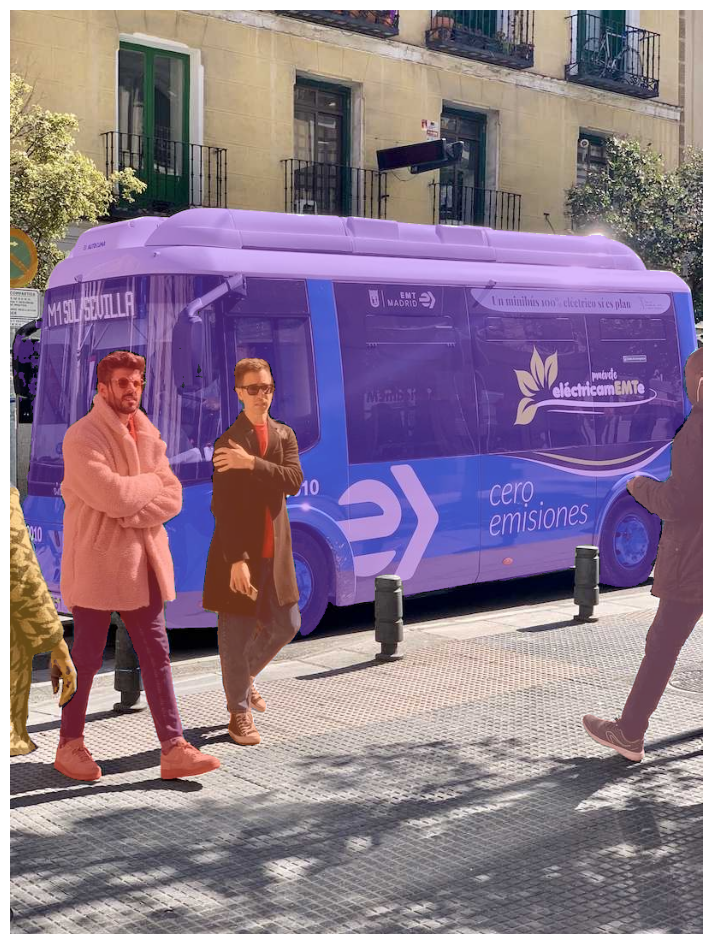

In [21]:
mask_annotated = mask_annotator.annotate(image.copy(), detections=sam_detections)
sv.plot_image(mask_annotated)

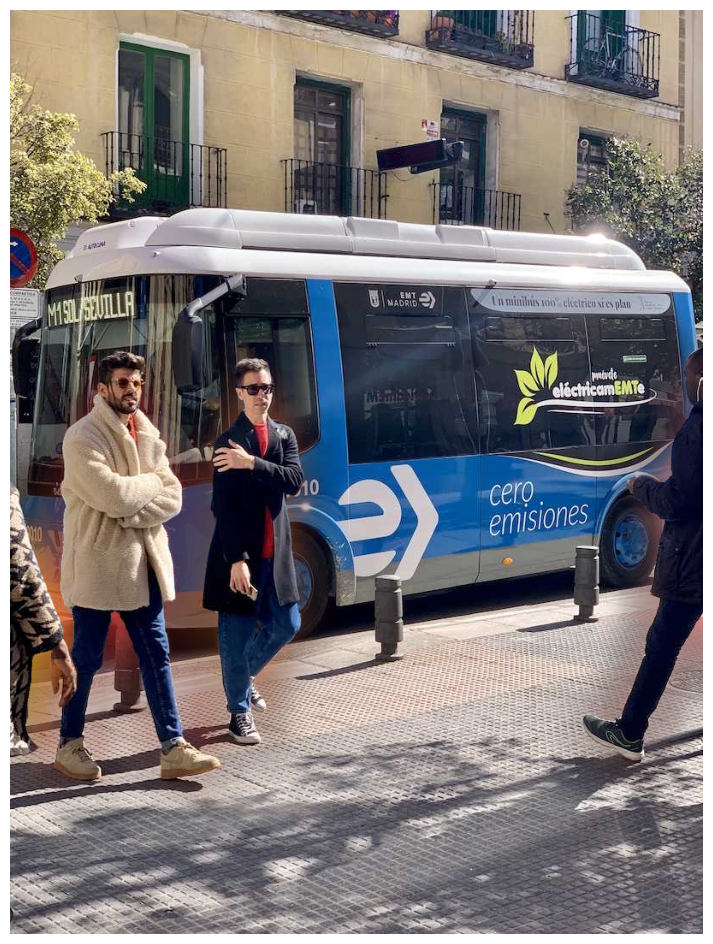

In [22]:
sam_persons = yolo_detections.class_id == 0
sam_detections_persons = sam_detections[sam_persons]
halo_annotated = halo_annotator.annotate(image.copy(), detections=sam_detections_persons)
sv.plot_image(halo_annotated)

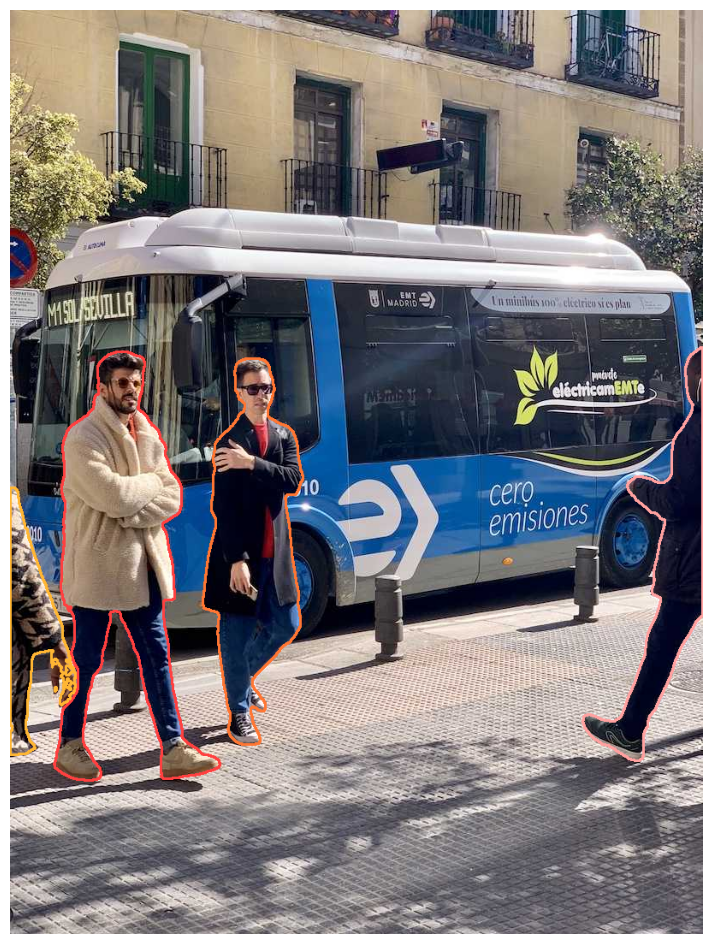

In [25]:
polygon_annotated = polygon_annotator.annotate(image.copy(), detections=sam_detections_persons)
sv.plot_image(polygon_annotated)